In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_points_around_circle(center_x, center_y, radius, num_points, noise_std):
    angles = np.random.uniform(0, 2*np.pi, num_points)

    # Вычисляем координаты точек на идеальной окружности по параметрическим уравнениям
    x_on_circle = center_x + radius * np.cos(angles)
    y_on_circle = center_y + radius * np.sin(angles)

    # Добавляем шум к каждой координате
    x_noisy = x_on_circle + np.random.normal(loc=0.0, scale=noise_std, size=num_points)
    y_noisy = y_on_circle + np.random.normal(loc=0.0, scale=noise_std, size=num_points)

    # Объединяем координаты в один массив размером (num_points, 2)
    points = np.column_stack((x_noisy, y_noisy))

    return points

In [3]:
group1 = generate_points_around_circle(2,3,2,100,0.05)

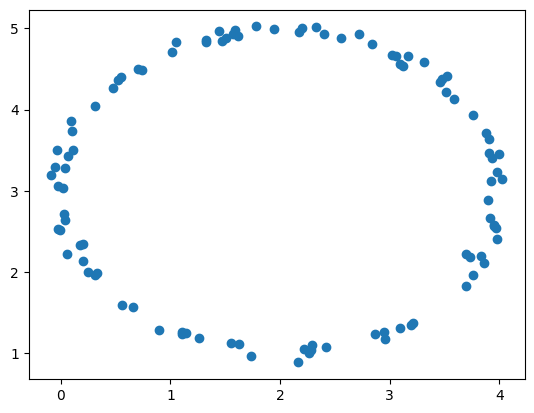

In [4]:
plt.scatter(group1[:,0], group1[:,1])

In [5]:
group2 = np.random.normal(loc=[2,3], scale=0.5, size=(100, 2))

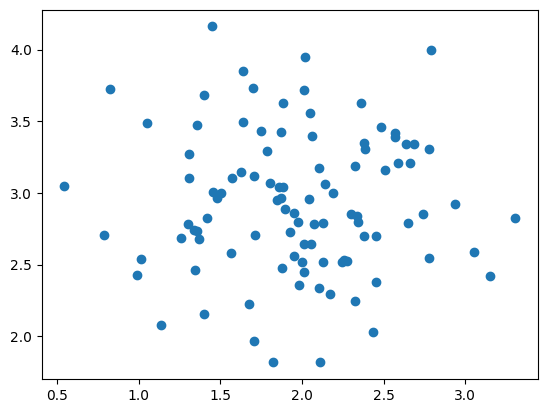

In [6]:
plt.scatter(group2[:,0], group2[:,1])

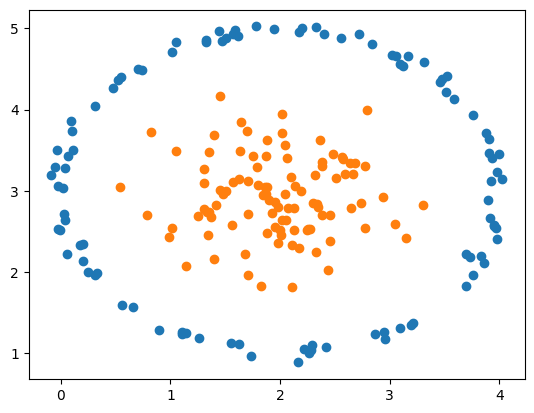

In [7]:
plt.scatter(group1[:,0], group1[:,1])
plt.scatter(group2[:,0], group2[:,1])

In [8]:
# входные значение должны быть представлены матрицей вида:
# | x_1, x_2, ... , x_N |
# | y_1, y_2, ... , y_N |
# однако матрицы group1, group2 и, как следствие, результат их конкатинации будет иметь вид:
# | x_1, y_1 |
# | x_2, y_2 |
#     ...
# поэтому матрицу со всеми точками необходимо транспонировать
points = np.concatenate((group1, group2)).T
targets = np.array([1.0]*100+[0.0]*100)

In [9]:
# класс нейросетевой модели
class NeuralNet:
    def __init__(self, hidden_size=10):
        # задаем веса двух слоев нейронной сети с hidden_size нейронами на первом слое
        self.w1 = np.random.normal(size=(hidden_size, 2))
        self.w2 = np.random.normal(size=(1,hidden_size))

    # сигмоида
    @staticmethod
    def activation(x):
        return 1.0 / (1.0 + np.exp(x))

    # функция потерь
    def loss(self, output, target):
        return np.mean(np.abs(target-output))

    # метод прямого прохода сигнала через нейронную сеть
    def forward(self, x, w1=None, w2=None):
        if w1 is None:
            w1 = self.w1
        if w2 is None:
            w2 = self.w2
            
        x = self.activation(w1@x)
        x = self.activation(w2@x)
        return x

    # метод шага обучения/оптимизации
    def train_step(self, x, target, lr=0.001):
        d_w1 = np.random.normal(size=self.w1.shape)
        d_w2 = np.random.normal(size=self.w2.shape)

        new_w1 = self.w1 + lr*d_w1
        new_w2 = self.w2 + lr*d_w2

        cur_output = self.forward(x)
        new_output = self.forward(x, new_w1, new_w2)

        if self.loss(cur_output, target) > self.loss(new_output, target):
            self.w1 = new_w1
            self.w2 = new_w2

In [25]:
model = NeuralNet()

# работа модели до обучения
model.forward(points)

array([[0.48438679, 0.44657261, 0.45163479, 0.47932557, 0.44515302,
        0.45668616, 0.48892563, 0.56589153, 0.55116768, 0.49446424,
        0.48962762, 0.48825483, 0.44374877, 0.45709446, 0.48715028,
        0.45470393, 0.49642563, 0.44551933, 0.4506107 , 0.52423578,
        0.44775613, 0.53468393, 0.48502291, 0.51930145, 0.46592467,
        0.46082604, 0.4911399 , 0.44358295, 0.44416875, 0.48542718,
        0.52298892, 0.49214637, 0.46855687, 0.48108651, 0.53164338,
        0.50275754, 0.44997622, 0.55060815, 0.44547301, 0.48520626,
        0.49234698, 0.49394074, 0.56326111, 0.44909536, 0.5513626 ,
        0.49228542, 0.56417244, 0.51442748, 0.4455179 , 0.46235699,
        0.49531185, 0.51171831, 0.47403806, 0.56072647, 0.51974732,
        0.44316284, 0.49197796, 0.44652553, 0.4912241 , 0.45700336,
        0.47198672, 0.45459722, 0.56312458, 0.5323026 , 0.44477547,
        0.44725759, 0.45293014, 0.50483396, 0.4441366 , 0.46350519,
        0.44428846, 0.52935319, 0.51252859, 0.52

In [26]:
# делаем много обучающих шагов
for _ in range(100_000):
    model.train_step(points, targets)

# работа модели после обучения
model.forward(points)

array([[9.99943204e-01, 1.94220977e-04, 2.17425613e-04, 9.99918684e-01,
        1.79496525e-06, 7.76561929e-03, 9.99956524e-01, 9.99904388e-01,
        9.99670663e-01, 9.96593151e-01, 9.99951898e-01, 9.99947058e-01,
        1.56046811e-06, 9.98218389e-01, 9.99942220e-01, 9.96375632e-01,
        9.99832450e-01, 1.94643405e-05, 4.84486033e-01, 8.80624521e-01,
        1.76271708e-05, 9.91921252e-01, 9.88289214e-01, 6.91082268e-01,
        4.42391115e-01, 9.99669973e-01, 9.99955530e-01, 1.70715053e-06,
        1.44867298e-06, 9.99942917e-01, 9.99692322e-01, 9.99966926e-01,
        9.99844249e-01, 9.81695421e-01, 9.99750535e-01, 9.84212954e-01,
        6.32093683e-05, 9.99664081e-01, 4.96995330e-05, 9.92527880e-01,
        9.99964476e-01, 9.99934885e-01, 9.99892047e-01, 1.29074933e-02,
        9.99862209e-01, 9.99959167e-01, 9.99895842e-01, 6.06862657e-01,
        2.02903063e-06, 9.99663227e-01, 9.99905007e-01, 9.99400978e-01,
        9.02999293e-01, 9.99874965e-01, 7.21217313e-01, 2.836421

In [27]:
# визуализация обученной модели
def plot_model(model, group1, group2):
    X_space = np.linspace(-1,6,40)
    Y_space = np.linspace(-1,6,40)
    
    t0, t1 = np.meshgrid(X_space, Y_space)
    
    Z = np.zeros_like(t0)
    
    for i, x in enumerate(X_space):
        for j, y in enumerate(Y_space):
            inp = np.array([
                [y],
                [x]
            ])
            Z[i,j] = model.forward(inp).item()
            
    plt.contourf(t0,t1,Z,levels=20)
    plt.scatter(group1[:,0], group1[:,1])
    plt.scatter(group2[:,0], group2[:,1])
    plt.show()

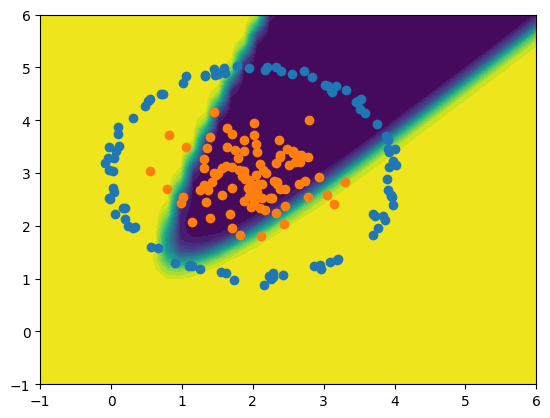

In [28]:
plot_model(model, group1, group2)

In [29]:
# класс нейросетевой модели с применением смещений в сумматоре
class NeuralNetBias:
    def __init__(self, hidden_size=10):
        self.w1 = np.random.normal(size=(hidden_size, 2))
        self.bias1 = np.random.normal(size=(hidden_size,1))
        
        self.w2 = np.random.normal(size=(1,hidden_size))
        self.bias2 = np.random.normal(size=(1,1))

    # сигмоида
    @staticmethod
    def activation(x):
        return 1.0 / (1.0 + np.exp(x))

    def loss(self, output, target):
        return np.mean(np.abs(target-output))

    def forward(self, x, w1=None, bias1=None, w2=None, bias2=None):
        if w1 is None:
            w1 = self.w1
        if w2 is None:
            w2 = self.w2
        if bias1 is None:
            bias1 = self.bias1
        if bias2 is None:
            bias2 = self.bias2
            
        x = self.activation(w1@x + bias1)
        x = self.activation(w2@x + bias2)
        return x

    def train_step(self, x, target, lr=0.001):
        d_w1 = np.random.normal(size=self.w1.shape)
        d_bias1 = np.random.normal(size=self.bias1.shape)
        
        d_w2 = np.random.normal(size=self.w2.shape)
        d_bias2 = np.random.normal(size=self.bias2.shape)

        new_w1 = self.w1 + lr*d_w1
        new_bias1 = self.bias1 + lr*d_bias1
        
        new_w2 = self.w2 + lr*d_w2
        new_bias2 = self.bias2 + lr*d_bias2

        cur_output = self.forward(x)
        new_output = self.forward(x, new_w1, new_bias1, new_w2, new_bias2)

        if self.loss(cur_output, target) > self.loss(new_output, target):
            self.w1 = new_w1
            self.bias1 = new_bias1
            
            self.w2 = new_w2
            self.bias2 = new_bias2

In [30]:
model_b = NeuralNetBias()

In [31]:
for _ in range(100_000):
    model_b.train_step(points, targets)

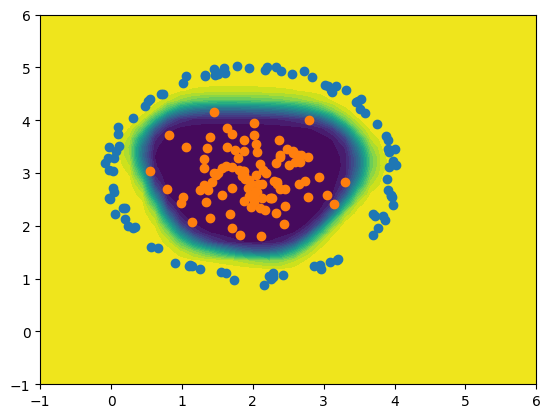

In [32]:
plot_model(model_b, group1, group2)

# Лабораторная работа 3
## 1. Модифицировать класс NeuralNetBias для решения задачи регрессии
## 2. Обучить модифицированную модель на точках (x,y) произвольно выбранной нелинейной функции
## 3. Вычислить при помощи обученной модели множество точек Y по множеству точек X
## 4. Визуализировать на одном изображении график выбранной функции и множество точек вычисленное в пункте 3
## *5. Вычислить точность обученной модели

---

примечание: за выполнение задания со звездочкой можно получить 2 дополнительных балла БРС (не распостраняется на сдачу без защиты). С примером готовой работы можно ознакомиться ниже

In [34]:
class NeuralNetBiasReg:
# *** Ваше решение ***

In [45]:
reg_model = NeuralNetBiasReg()

X = np.linspace(-5,5,200)
# для реалистичности по желанию можно добавить шум в обучающие данные
Y = np.sin(X) + 0.5*X + 0.1*np.random.normal(size=X.shape)

# X и Y представлены в виде строки, а должены быть поданы как вырожденные в строки матрицы
# поэтому через expand_dims добаляем им новое пустое измерение
X_train = np.expand_dims(X, axis=0)
Y_train = np.expand_dims(Y, axis=0)

for _ in range(100_000):
    reg_model.train_step(X_train, Y_train)

In [46]:
output = reg_model.forward(X_train)

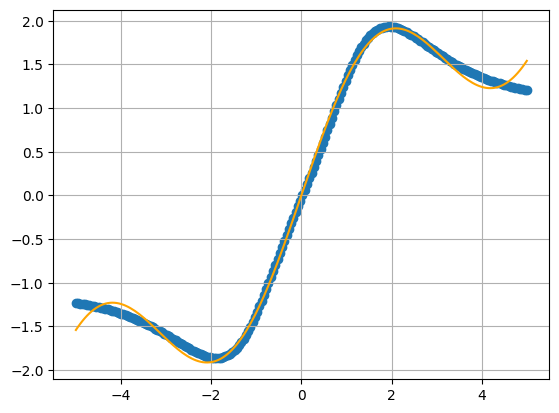

In [47]:
plt.scatter(X, output[0])
plt.plot(X, np.sin(X) + 0.5*X, color='orange')
plt.grid()